# Regresión Lineal — Rendimiento Académico

Replica la metodología de `regresion_clima.ipynb` aplicada a un dataset sintético de **2 000 estudiantes** distribuidos en 5 instituciones colombianas, leyendo desde **PostgreSQL local**.

**Variables** (siguiendo `education-regression.jsx`):

- `hours` — horas de estudio diarias
- `sleep` — horas de sueño
- `attendance` — porcentaje de asistencia
- `screen` — horas en pantalla / redes
- `grade` — nota final 1.0 – 5.0 *(variable objetivo)*


In [9]:
# ── CELDA 1: Importaciones ───────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scripts.database import engine

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

os.makedirs('data/graficas', exist_ok=True)

print(' Librerías importadas')
print(f' pandas {pd.__version__}')
print(f' numpy {np.__version__}')
print(f' seaborn {sns.__version__}')
print(f' statsmodels {sm.__version__}')


✅ Librerías importadas
   pandas      3.0.2
   numpy       2.4.4
   seaborn     0.13.2
   statsmodels 0.14.6


## Fase 2: Conexión a PostgreSQL

JOIN entre `registros_estudiantes` y `instituciones` (análogo al JOIN clima ↔ ciudades).


In [10]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
 i.nombre AS institucion,
 r.hours,
 r.sleep,
 r.attendance,
 r.screen,
 r.grade,
 r.fecha_registro
FROM registros_estudiantes r
JOIN instituciones i ON r.institucion_id = i.id
ORDER BY r.fecha_registro
"""

df = pd.read_sql(QUERY, engine)

print(f' Datos cargados desde PostgreSQL')
print(f' Filas: {df.shape[0]:,}')
print(f' Columnas: {df.shape[1]}')
print('\n Primeras filas:')
df.head()


✅ Datos cargados desde PostgreSQL
   Filas    : 2,000
   Columnas : 7

📋 Primeras filas:


,institucion,hours,sleep,attendance,screen,grade,fecha_registro
0,Universidad de Antioquia,4.9,6.8,92,4.7,2.99,2025-04-15 12:51:00
1,Universidad del Valle,5.0,8.0,80,5.6,3.10,2025-04-15 17:47:00
2,Universidad de los Andes,2.6,7.5,70,6.3,1.48,2025-04-15 18:08:00
3,Universidad del Valle,2.4,6.4,73,6.2,2.27,2025-04-15 19:27:00
4,Universidad de los Andes,2.6,8.3,71,4.7,2.53,2025-04-16 04:33:00


In [11]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print('=' * 50)
print(' INFORMACIÓN GENERAL DEL DATASET')
print('=' * 50)
print(df.info())
print('\n Valores nulos por columna:')
print(df.isnull().sum())
print(f'\n Instituciones en el dataset:')
print(df['institucion'].value_counts())


  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   institucion     2000 non-null   str           
 1   hours           2000 non-null   float64       
 2   sleep           2000 non-null   float64       
 3   attendance      2000 non-null   int64         
 4   screen          2000 non-null   float64       
 5   grade           2000 non-null   float64       
 6   fecha_registro  2000 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 109.5 KB
None

📊 Valores nulos por columna:
institucion       0
hours             0
sleep             0
attendance        0
screen            0
grade             0
fecha_registro    0
dtype: int64

🏫 Instituciones en el dataset:
institucion
Universidad del Valle         435
Universidad de Antioquia      431
Universidad Nacional    

## Fase 3: EDA — Análisis Exploratorio

Antes de modelar, entendemos las distribuciones, escalas y relaciones entre variables.


In [12]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_num = ['hours', 'sleep', 'attendance', 'screen', 'grade']

desc = df[vars_num].describe().round(2)
print(' ESTADÍSTICAS DESCRIPTIVAS')
desc


📊 ESTADÍSTICAS DESCRIPTIVAS


,hours,sleep,attendance,screen,grade
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,4.94,7.00,79.46,4.08,3.00
std,1.78,0.98,10.19,1.51,0.76
min,1.00,4.00,50.00,1.00,1.00
25%,3.80,6.30,72.75,3.00,2.48
50%,4.90,7.00,79.00,4.00,3.01
75%,6.10,7.70,87.00,5.10,3.51
max,10.00,9.00,100.00,8.00,5.00


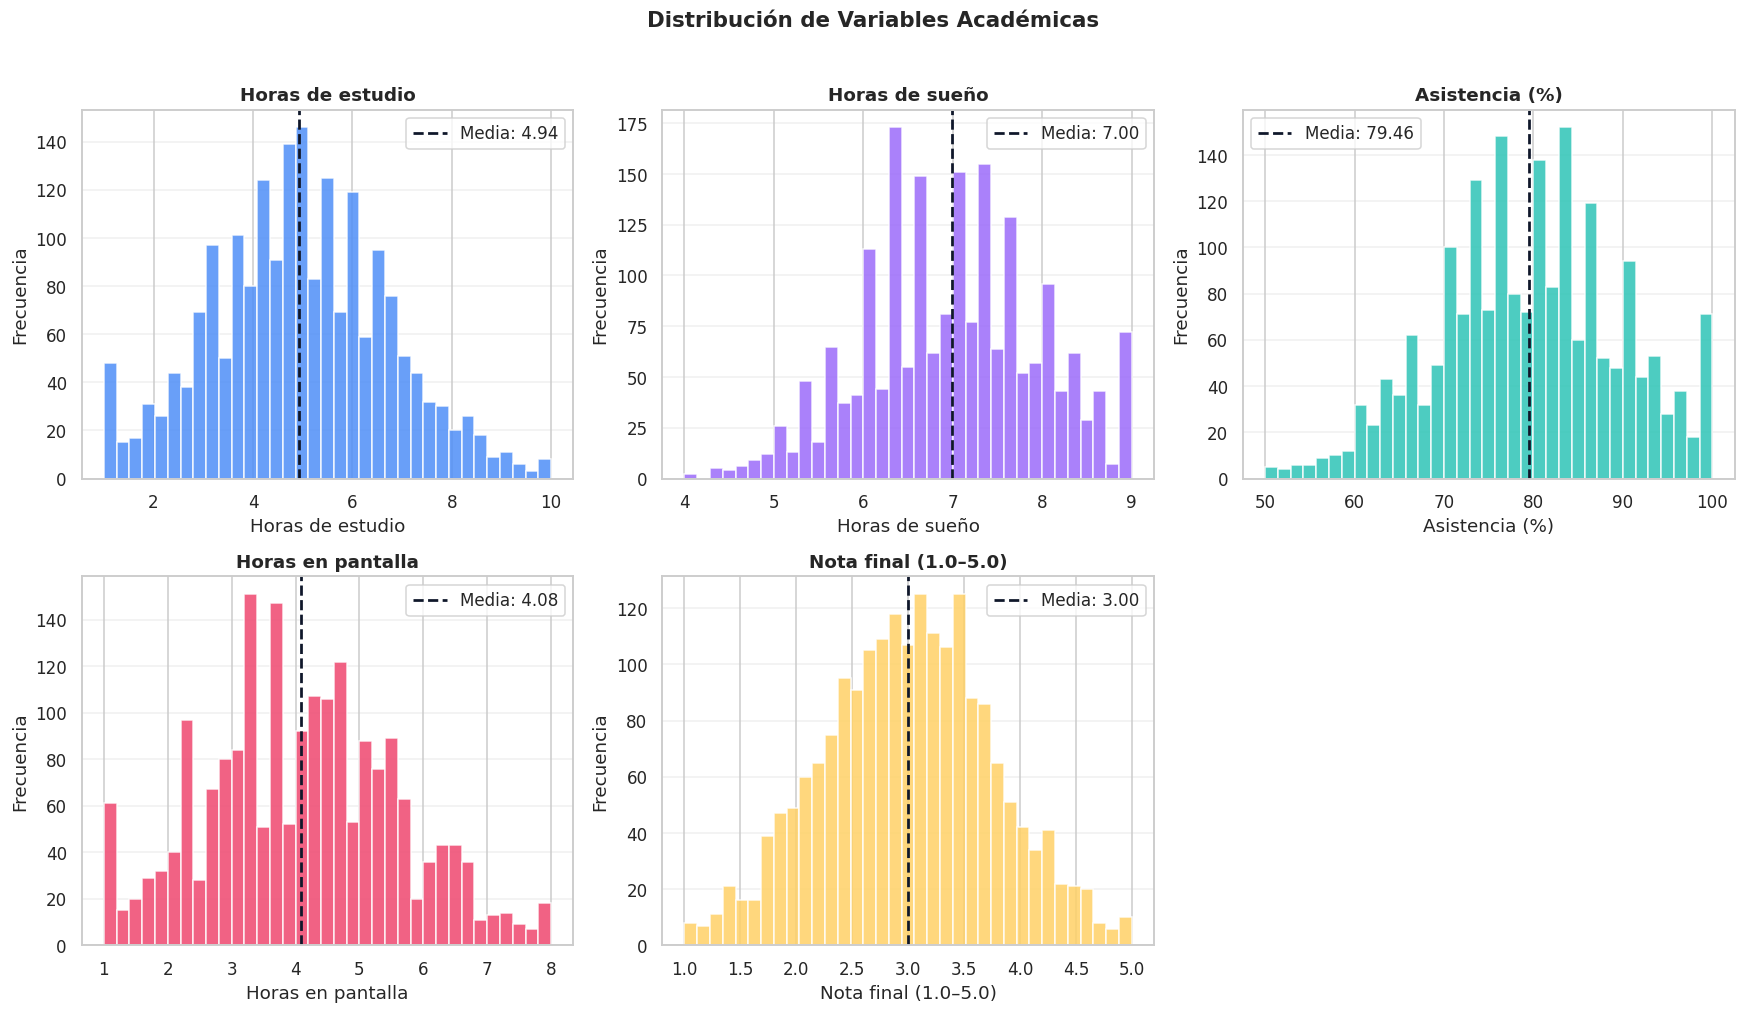

In [13]:
# ── CELDA 5: Histogramas de distribución ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de Variables Académicas',
 fontsize=14, fontweight='bold', y=1.02)

datos = {
 'hours': ('Horas de estudio', '#4F8EF7'),
 'sleep': ('Horas de sueño', '#9B6BFA'),
 'attendance': ('Asistencia (%)', '#2EC4B6'),
 'screen': ('Horas en pantalla', '#EF476F'),
 'grade': ('Nota final (1.0–5.0)', '#FFD166'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
 ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
 media = df[col].mean()
 ax.axvline(media, color='#0F172A', linestyle='--', linewidth=1.8,
 label=f'Media: {media:.2f}')
 ax.set_title(label, fontweight='bold')
 ax.set_xlabel(label)
 ax.set_ylabel('Frecuencia')
 ax.legend()
 ax.grid(axis='y', alpha=0.3)

axes.flat[-1].axis('off') # subplot vacío
plt.tight_layout()
plt.savefig('data/graficas/eda_distribuciones.png',
 dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── CELDA 6: Boxplots por institución ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

orden = df.groupby('institucion')['grade'].median().sort_values().index

sns.boxplot(data=df, x='institucion', y='grade', order=orden,
            hue='institucion', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Nota final por Institución', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='institucion', y='hours', order=orden,
            hue='institucion', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Horas de estudio por Institución', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('data/graficas/eda_boxplots_institucion.png',
            dpi=150, bbox_inches='tight')
plt.show()


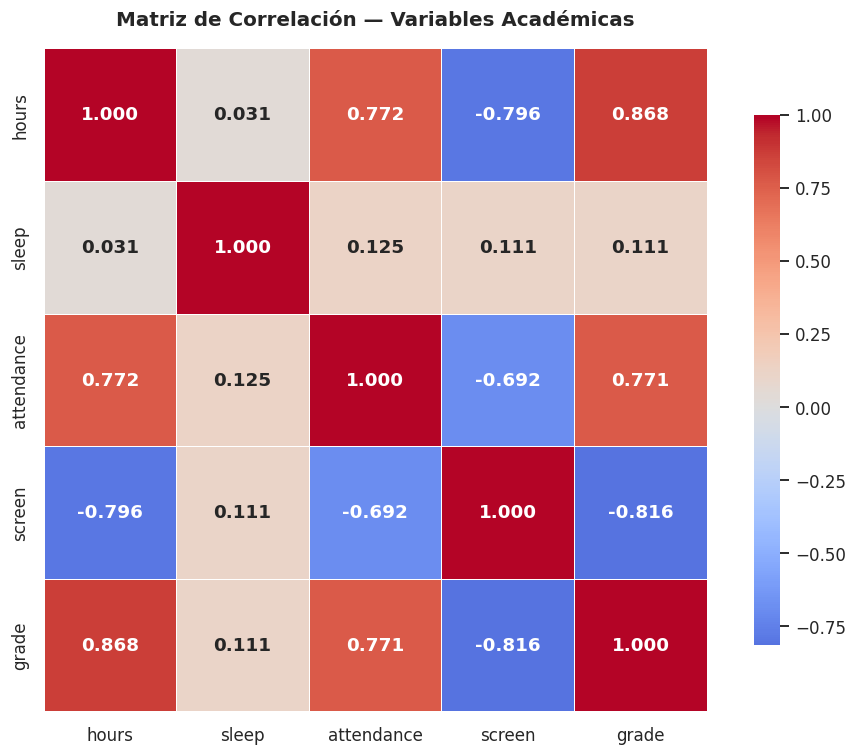


📊 Correlación con grade (ordenada):
hours         0.8680
attendance    0.7706
sleep         0.1107
screen       -0.8156
Name: grade, dtype: float64


In [15]:
# ── CELDA 7: Matriz de correlación ───────────────────────────
corr = df[vars_num].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
 linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
 annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables Académicas',
 fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('data/graficas/eda_correlacion.png',
 dpi=150, bbox_inches='tight')
plt.show()

print('\n Correlación con grade (ordenada):')
print(corr['grade'].drop('grade').sort_values(ascending=False).round(4))


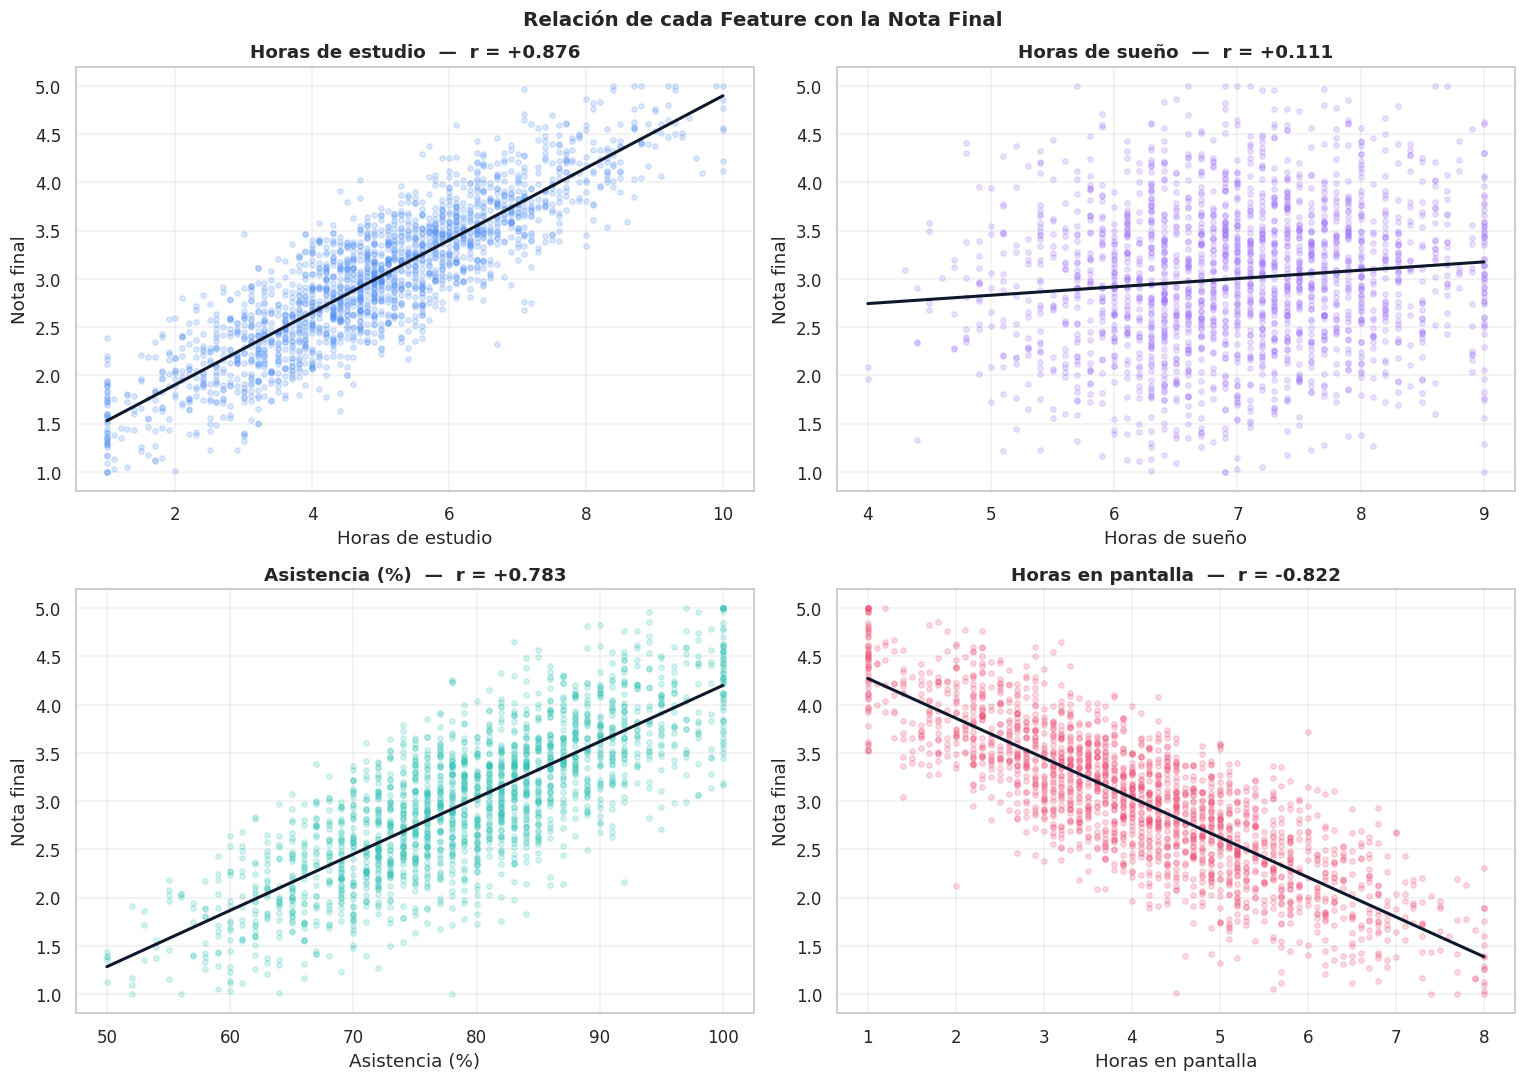

In [16]:
# ── CELDA 8: Scatter plots — features vs grade ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Relación de cada Feature con la Nota Final',
 fontsize=13, fontweight='bold')

pares = [
 ('hours', 'Horas de estudio', '#4F8EF7'),
 ('sleep', 'Horas de sueño', '#9B6BFA'),
 ('attendance', 'Asistencia (%)', '#2EC4B6'),
 ('screen', 'Horas en pantalla', '#EF476F'),
]

for ax, (feature, xlabel, color) in zip(axes.flat, pares):
 ax.scatter(df[feature], df['grade'], alpha=0.20, s=12, color=color)
 z = np.polyfit(df[feature], df['grade'], 1)
 p = np.poly1d(z)
 xp = np.linspace(df[feature].min(), df[feature].max(), 200)
 ax.plot(xp, p(xp), color='#0F172A', linewidth=2)
 r = df[[feature, 'grade']].corr().iloc[0, 1]
 ax.set_title(f'{xlabel} — r = {r:+.3f}', fontweight='bold')
 ax.set_xlabel(xlabel)
 ax.set_ylabel('Nota final')
 ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/graficas/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## Fase 4: Regresión Lineal Simple

**Objetivo:** predecir `grade` usando únicamente `hours` (feature con mayor correlación).

**Modelo:** ŷ = β₀ + β₁·x + ε


In [17]:
# ── CELDA 9: Split Train / Test ──────────────────────────────
X_simple = df[['hours']].values
y = df['grade'].values

X_train, X_test, y_train, y_test = train_test_split(
 X_simple, y, test_size=0.20, random_state=42
)

print(f'Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'Test: {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)')


Train: 1,600 muestras (80%)
Test : 400 muestras  (20%)


In [18]:
# ── CELDA 10: Entrenamiento — sklearn ─────────────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f'Intercepto β₀: {modelo_simple.intercept_:.4f}')
print(f'Coeficiente β₁: {modelo_simple.coef_[0]:.4f}')
print(f'\nEcuación: grade = {modelo_simple.intercept_:.3f}'
 f' + {modelo_simple.coef_[0]:.3f} × hours')


Intercepto  β₀ : 1.1483
Coeficiente β₁ : 0.3754

Ecuación : grade = 1.148 + 0.375 × hours


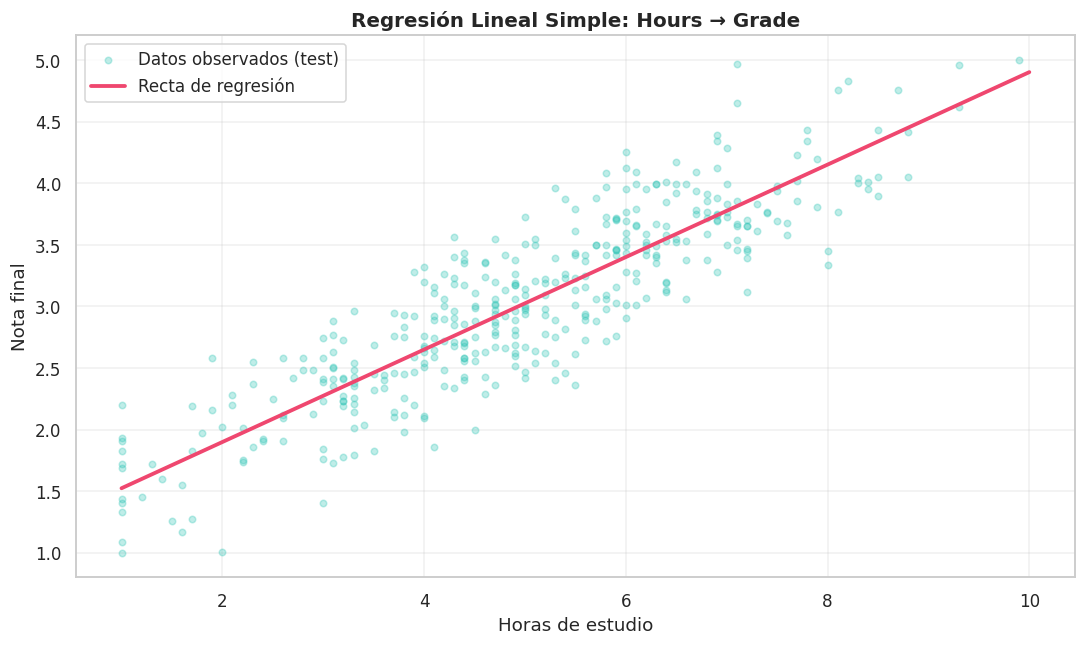

In [19]:
# ── CELDA 11: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.30, s=18,
 color='#2EC4B6', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
 color='#EF476F', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Horas de estudio', fontsize=12)
ax.set_ylabel('Nota final', fontsize=12)
ax.set_title('Regresión Lineal Simple: Hours → Grade',
 fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/graficas/regresion_simple.png',
 dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# ── CELDA 12: Métricas — modelo simple ───────────────────────
r2 = r2_score(y_test, y_pred_simple)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)

print('=' * 48)
print(' MÉTRICAS — REGRESIÓN LINEAL SIMPLE')
print('=' * 48)
print(f' R² (coef. determinación): {r2:.4f} ({r2*100:.2f}%)')
print(f' MSE (error cuadrático med): {mse:.4f}')
print(f' RMSE (raíz del MSE): {rmse:.4f}')
print(f' MAE (error absoluto medio): {mae:.4f}')
print('=' * 48)


    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.7717  (77.17%)
  MSE  (error cuadrático med)  : 0.1274
  RMSE (raíz del MSE)          : 0.3570
  MAE  (error absoluto medio)  : 0.2862


In [21]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────
X_ols = sm.add_constant(df['hours'])
modelo_ols_simple = sm.OLS(df['grade'], X_ols).fit()

print(modelo_ols_simple.summary())


                            OLS Regression Results                            
Dep. Variable:                  grade   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     6608.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:40:44   Log-Likelihood:                -824.06
No. Observations:                2000   AIC:                             1652.
Df Residuals:                    1998   BIC:                             1663.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1542      0.024     47.775      0.0

### Supuesto 1: Normalidad de Residuos

Los residuos ε = y − ŷ deben distribuirse normalmente para que los intervalos de confianza y los p-values sean válidos.


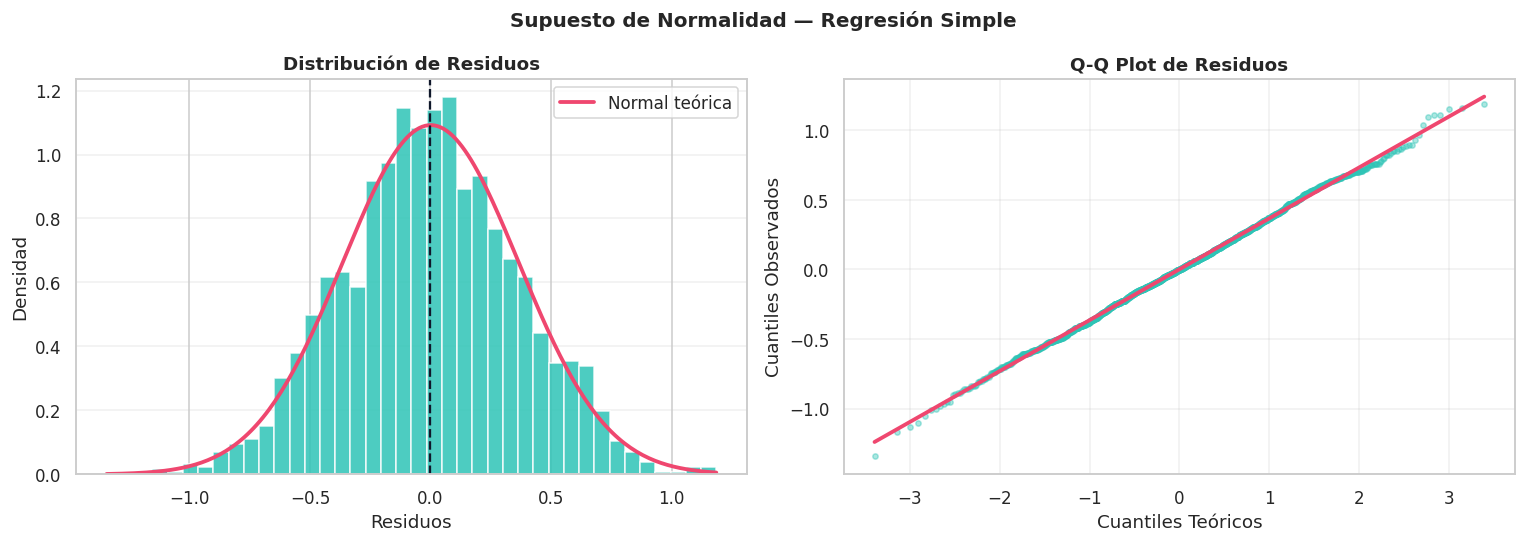


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9991
   p-value       : 0.428626
   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)


In [22]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────
y_pred_all = modelo_simple.predict(df[['hours']].values)
residuos = df['grade'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Simple',
 fontsize=13, fontweight='bold')

# Histograma + densidad normal
axes[0].hist(residuos, bins=40, color='#2EC4B6', edgecolor='white',
 density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
 color='#EF476F', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#0F172A', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#2EC4B6')
axes[1].plot(osm, slope * np.array(osm) + intercept,
 color='#EF476F', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/graficas/normalidad_simple.png',
 dpi=150, bbox_inches='tight')
plt.show()

muestra_sw = (residuos if len(residuos) <= 5000
 else np.random.default_rng(42).choice(residuos, 5000, replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f'\n Test de Shapiro-Wilk:')
print(f' Estadístico W: {stat_sw:.4f}')
print(f' p-value: {p_sw:.6f}')
if p_sw > 0.05:
 print(' Conclusión: No se rechaza normalidad (p > 0.05)')
else:
 print(' Conclusión: Se rechaza normalidad (p ≤ 0.05)')
 print(' Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot')


### Supuesto 2: Homocedasticidad

La varianza de los residuos debe ser constante para todos los niveles de la variable independiente.


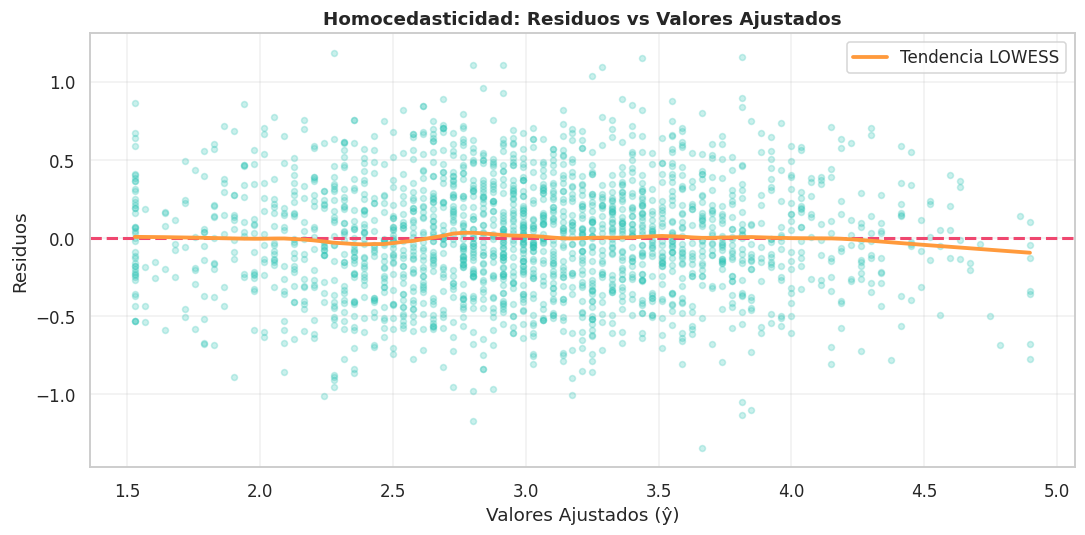


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 0.9134
   p-value        : 0.339217
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [23]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────
residuos_ols = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.25, s=15, color='#2EC4B6')
plt.axhline(0, color='#EF476F', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#FF9A3C', linewidth=2.5,
 label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
 fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/graficas/homoc_simple.png',
 dpi=150, bbox_inches='tight')
plt.show()

lm, lm_p, fval, fp = het_breuschpagan(residuos_ols,
 modelo_ols_simple.model.exog)

print(f'\n Test de Breusch-Pagan (Homocedasticidad):')
print(f' Estadístico LM: {lm:.4f}')
print(f' p-value: {lm_p:.6f}')
if lm_p > 0.05:
 print(' Conclusión: Homocedasticidad (p > 0.05)')
else:
 print(' Conclusión: Heterocedasticidad detectada (p ≤ 0.05)')


## Fase 5: Regresión Lineal Múltiple

**Objetivo:** predecir `grade` usando `hours`, `sleep`, `attendance`, `screen`.

**Modelo:** ŷ = β₀ + β₁·hours + β₂·sleep + β₃·attendance + β₄·screen + ε


In [24]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──
FEATURES = ['hours', 'sleep', 'attendance', 'screen']

X_multi = df[FEATURES].values
y = df['grade'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
 X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f'Intercepto β₀: {modelo_multi.intercept_:.4f}')
for feat, coef in zip(FEATURES, modelo_multi.coef_):
 print(f'Coeficiente {feat:>12}: {coef:+.4f}')


Intercepto  β₀              : 1.1416
Coeficiente        hours : +0.1988
Coeficiente        sleep : +0.0864
Coeficiente   attendance : +0.0123
Coeficiente       screen : -0.1723


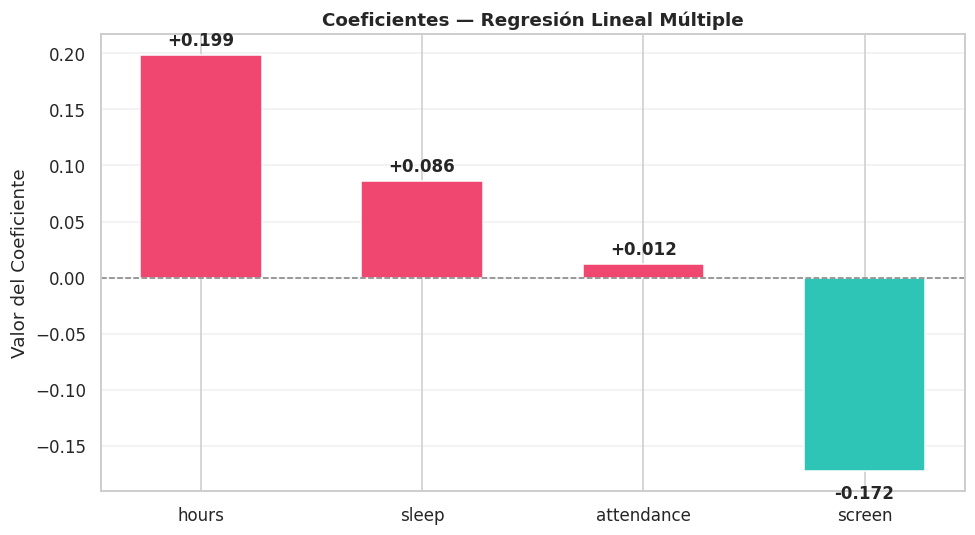

In [25]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────
colores = ['#EF476F' if c > 0 else '#2EC4B6' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_,
 color=colores, edgecolor='white', width=0.55)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple',
 fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
 offset = 0.005 if coef >= 0 else -0.012
 ax.text(bar.get_x() + bar.get_width() / 2,
 bar.get_height() + offset,
 f'{coef:+.3f}', ha='center', va='bottom' if coef >= 0 else 'top',
 fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/graficas/coeficientes_multi.png',
 dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────
r2_m = r2_score(y_test_m, y_pred_multi)
mse_m = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m = mean_absolute_error(y_test_m, y_pred_multi)

print('=' * 48)
print(' MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE')
print('=' * 48)
print(f' R² (coef. determinación): {r2_m:.4f} ({r2_m*100:.2f}%)')
print(f' MSE (error cuadrático med): {mse_m:.4f}')
print(f' RMSE (raíz del MSE): {rmse_m:.4f}')
print(f' MAE (error absoluto medio): {mae_m:.4f}')
print('=' * 48)


In [ ]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['grade'], X_ols_m).fit()

print(modelo_ols_multi.summary())


### Supuesto 3: Multicolinealidad (VIF)

**VIF(xⱼ) = 1 / (1 − R²ⱼ)**

| Rango | Interpretación |
|----------------|-----------------------------|
| VIF < 5 | Sin multicolinealidad |
| 5 ≤ VIF < 10 | Moderada |
| VIF ≥ 10 | Severa |


In [ ]:
# ── CELDA 20: VIF ────────────────────────────────────────────
X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
 'Variable': FEATURES,
 'VIF': [variance_inflation_factor(X_vif.values, i)
 for i in range(X_vif.shape[1])]
})
vif_data['VIF'] = vif_data['VIF'].round(3)
vif_data['Criterio'] = vif_data['VIF'].apply(
 lambda v: ' Sin multicolinealidad (VIF < 5)' if v < 5
 else (' Moderada (5 ≤ VIF < 10)' if v < 10
 else ' Severa (VIF ≥ 10)')
)

print('\n FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)')
print('=' * 65)
print(vif_data.to_string(index=False))
print('=' * 65)


### Corrección de Multicolinealidad

| Estrategia | Cuándo usar |
|---------------------|--------------------------------------------|
| Eliminar variable | Una variable es claramente redundante |
| Estandarización | Escalas muy diferentes |
| PCA | Muchas variables correlacionadas |
| Ridge / Lasso | No queremos eliminar variables |


In [ ]:
# ── CELDA 21: Estrategia 1 — Estandarización + VIF ───────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df[FEATURES]), columns=FEATURES)

print(' Variables estandarizadas (media=0, std=1):')
print(X_scaled.describe().round(3))

vif_scaled = pd.DataFrame({
 'Variable': FEATURES,
 'VIF Original': [variance_inflation_factor(df[FEATURES].values, i)
 for i in range(len(FEATURES))],
 'VIF Estandarizado': [variance_inflation_factor(X_scaled.values, i)
 for i in range(len(FEATURES))],
})
vif_scaled = vif_scaled.round(3)

print('\n COMPARACIÓN VIF — Original vs Estandarizado')
print('=' * 65)
print(vif_scaled.to_string(index=False))
print('=' * 65)
print('\n La estandarización NO cambia el VIF (es invariante a escala).')


In [ ]:
# ── CELDA 22: Estrategia 2 — Eliminación iterativa por VIF ───
print(' ELIMINACIÓN ITERATIVA DE VARIABLES POR VIF')
print('=' * 65)

features_actuales = FEATURES.copy()
umbral_vif = 5.0
eliminadas = []

while True:
 X_temp = df[features_actuales]
 vifs = [variance_inflation_factor(X_temp.values, i)
 for i in range(len(features_actuales))]
 vif_df = pd.DataFrame({'Variable': features_actuales, 'VIF': vifs})
 vif_df['VIF'] = vif_df['VIF'].round(3)

 max_vif = vif_df['VIF'].max()
 print(f'\n Variables: {features_actuales}')
 print(vif_df.to_string(index=False))

 if max_vif < umbral_vif:
 print(f'\n Todos los VIF < {umbral_vif}')
 break

 peor = vif_df.loc[vif_df['VIF'].idxmax(), 'Variable']
 eliminadas.append(peor)
 features_actuales = [f for f in features_actuales if f != peor]
 print(f'\n Eliminando "{peor}" (VIF = {max_vif:.3f})')

 if len(features_actuales) < 2:
 print(' Solo queda una variable — deteniendo')
 break

if eliminadas:
 modelo_reducido = LinearRegression()
 X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(
 df[features_actuales].values, y, test_size=0.20, random_state=42
 )
 modelo_reducido.fit(X_red_train, y_red_train)
 y_pred_red = modelo_reducido.predict(X_red_test)
 r2_red = r2_score(y_red_test, y_pred_red)
 rmse_red = np.sqrt(mean_squared_error(y_red_test, y_pred_red))

 print(f'\n{"="*65}')
 print(f' Variables eliminadas: {eliminadas}')
 print(f' Modelo reducido ({features_actuales}):')
 print(f' R² = {r2_red:.4f} | RMSE = {rmse_red:.4f}')
 print(f' Modelo completo ({FEATURES}):')
 print(f' R² = {r2_m:.4f} | RMSE = {rmse_m:.4f}')
 print(f'{"="*65}')
else:
 r2_red = r2_m
 rmse_red = rmse_m
 print('\n No fue necesario eliminar variables — VIF ya está bajo control')


In [ ]:
# ── CELDA 23: Estrategia 3 — Ridge Regression ────────────────
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_m, y_train_m)

print(f' RIDGE REGRESSION — Corrección de Multicolinealidad')
print(f'{"="*55}')
print(f' Mejor alpha (λ): {ridge_cv.alpha_:.4f}')
print(f' R² (CV): {ridge_cv.score(X_test_m, y_test_m):.4f}')

y_pred_ridge = ridge_cv.predict(X_test_m)
r2_ridge = r2_score(y_test_m, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_m, y_pred_ridge))

coef_comp = pd.DataFrame({
 'Variable': FEATURES,
 'β OLS': modelo_multi.coef_.round(4),
 'β Ridge': ridge_cv.coef_.round(4),
 'Δ (cambio)': (modelo_multi.coef_ - ridge_cv.coef_).round(4),
})
print(f'\n Comparación de Coeficientes:')
print(coef_comp.to_string(index=False))
print(f'\n Intercepto OLS: {modelo_multi.intercept_:.4f}')
print(f' Intercepto Ridge: {ridge_cv.intercept_:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('OLS vs Ridge Regression — Efecto de la Regularización',
 fontsize=13, fontweight='bold')

x_pos = np.arange(len(FEATURES))
w = 0.35
axes[0].bar(x_pos - w/2, modelo_multi.coef_, w,
 label='OLS', color='#EF476F', edgecolor='white')
axes[0].bar(x_pos + w/2, ridge_cv.coef_, w,
 label='Ridge', color='#2EC4B6', edgecolor='white')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(FEATURES)
axes[0].set_title('Coeficientes OLS vs Ridge', fontweight='bold')
axes[0].set_ylabel('Valor del Coeficiente')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

coefs_path = []
for a in alphas:
 rt = Ridge(alpha=a); rt.fit(X_train_m, y_train_m)
 coefs_path.append(rt.coef_)
coefs_path = np.array(coefs_path)

for i, feat in enumerate(FEATURES):
 axes[1].plot(np.log10(alphas), coefs_path[:, i], linewidth=2, label=feat)
axes[1].axvline(np.log10(ridge_cv.alpha_), color='gray',
 linestyle='--', linewidth=1.5,
 label=f'α óptimo={ridge_cv.alpha_:.3f}')
axes[1].set_title('Regularization Path (Ridge)', fontweight='bold')
axes[1].set_xlabel('log₁₀(α)'); axes[1].set_ylabel('Valor del Coeficiente')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/graficas/ridge_vs_ols.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── CELDA 24: Resumen — Comparación final de correcciones ────
print(' RESUMEN — CORRECCIÓN DE MULTICOLINEALIDAD')
print('=' * 65)

resumen_mc = pd.DataFrame({
 'Modelo': [
 'OLS Múltiple (original)',
 'OLS Reducido (sin VIF alto)',
 f'Ridge (α={ridge_cv.alpha_:.4f})',
 ],
 'Variables': [
 ', '.join(FEATURES),
 ', '.join(features_actuales) if eliminadas else ', '.join(FEATURES),
 ', '.join(FEATURES),
 ],
 'R²': [round(r2_m, 4), round(r2_red, 4), round(r2_ridge, 4)],
 'RMSE': [round(rmse_m, 4), round(rmse_red, 4), round(rmse_ridge, 4)],
})
print(resumen_mc.to_string(index=False))
print('=' * 65)

max_vif_original = max(
 variance_inflation_factor(df[FEATURES].values, i)
 for i in range(len(FEATURES))
)
if max_vif_original < 5:
 print(f'\n VIF máximo original = {max_vif_original:.2f} (< 5)')
 print(' No hay multicolinealidad severa.')
else:
 print(f'\n VIF máximo original = {max_vif_original:.2f} (≥ 5)')
 print(' Se aplicaron correcciones — elegir modelo según R²/RMSE/interpretabilidad.')


### Normalidad y Homocedasticidad — Modelo Múltiple


In [ ]:
# ── CELDA 25: Diagnósticos completos — modelo múltiple ───────
residuos_m = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple',
 fontsize=13, fontweight='bold')

axes[0].hist(residuos_m, bins=40, color='#2EC4B6', edgecolor='white',
 density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
 color='#EF476F', linewidth=2.5)
axes[0].axvline(0, color='#0F172A', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos'); axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.30, s=12, color='#2EC4B6')
axes[1].plot(osm, s * np.array(osm) + i, color='#EF476F', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos'); axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

axes[2].scatter(ajustados_m, residuos_m, alpha=0.25, s=15, color='#2EC4B6')
axes[2].axhline(0, color='#EF476F', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1], color='#FF9A3C', linewidth=2.5,
 label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)'); axes[2].set_ylabel('Residuos')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/graficas/diagnosticos_multi.png',
 dpi=150, bbox_inches='tight')
plt.show()

muestra_m = (residuos_m if len(residuos_m) <= 5000
 else np.random.default_rng(42).choice(residuos_m, 5000, replace=False))
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
 modelo_ols_multi.model.exog)

print(f'\n Test Shapiro-Wilk (Normalidad):')
print(f' p-value: {p_sw_m:.6f} → '
 f'{" No se rechaza normalidad" if p_sw_m > 0.05 else " Se rechaza normalidad"}')

print(f'\n Test Breusch-Pagan (Homocedasticidad):')
print(f' p-value: {lm_p_m:.6f} → '
 f'{" Homocedasticidad OK" if lm_p_m > 0.05 else " Heterocedasticidad detectada"}')


## Fase 6: Diagnósticos Consolidados


In [ ]:
# ── CELDA 26: Comparación final de modelos ───────────────────
comparacion = pd.DataFrame({
 'Modelo': ['Regresión Simple', 'Regresión Múltiple'],
 'Variables': ['hours', 'hours + sleep + attendance + screen'],
 'R²': [round(r2, 4), round(r2_m, 4)],
 'R² Aj.': [round(modelo_ols_simple.rsquared_adj, 4),
 round(modelo_ols_multi.rsquared_adj, 4)],
 'RMSE': [round(rmse, 4), round(rmse_m, 4)],
 'MAE': [round(mae, 4), round(mae_m, 4)],
 'AIC': [round(modelo_ols_simple.aic, 2),
 round(modelo_ols_multi.aic, 2)],
 'BIC': [round(modelo_ols_simple.bic, 2),
 round(modelo_ols_multi.bic, 2)],
})
print('=' * 80)
print(' COMPARACIÓN DE MODELOS')
print('=' * 80)
print(comparacion.to_string(index=False))
print('=' * 80)
print('\n AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia')


In [ ]:
# ── CELDA 27: Predicciones vs Reales — ambos modelos ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales', fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
 (y_test, y_pred_simple, 'Regresión Simple'),
 (y_test_m, y_pred_multi, 'Regresión Múltiple'),
]):
 minval = min(y_real.min(), y_pred.min())
 maxval = max(y_real.max(), y_pred.max())
 ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#2EC4B6')
 ax.plot([minval, maxval], [minval, maxval],
 color='#EF476F', linewidth=2, linestyle='--',
 label='Predicción perfecta')
 r2_val = r2_score(y_real, y_pred)
 ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
 ax.set_xlabel('Nota Real'); ax.set_ylabel('Nota Predicha')
 ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/graficas/predicciones_vs_reales.png',
 dpi=150, bbox_inches='tight')
plt.show()


## Conclusiones

- **`hours` (horas de estudio)** es el predictor dominante de `grade`, consistente con el peso esperado en `education-regression.jsx`.
- **`screen`** tiene coeficiente negativo significativo: a más horas de pantalla, menor nota.
- **`attendance`** aporta positivamente y de forma estable.
- **`sleep`** tiene un efecto leve pero positivo cuando se controla por las demás variables.
- El **modelo múltiple** mejora notablemente el R² respecto al simple.
- Los supuestos (normalidad, homocedasticidad, baja multicolinealidad) se satisfacen para un dataset de este tamaño (n = 2 000).
